In [14]:
# using Pkg; Pkg.instantiate() # if error, resets config; delete Manifest.toml first, then run this code
using Revise
using Printf
using LinearAlgebra
using PyPlot
using FFTW
using MultiModeNoise
using NPZ

This should be the same figure as 3a in Dudley, John M., Goëry Genty, and Stéphane Coen. "Supercontinuum generation in photonic crystal fiber." Reviews of modern physics 78.4 (2006): 1135-1184.

# Setting up initial conditions

In [ ]:
λ0 = 835e-9 # m
M = 1 # number of sp modes
Nt = 2^12 # 2^10, frequency bins
time_window = 10 # ps, range of pulse
β_order = 10; # mode order: 0, 1, 2, ...


# User Defined gammas and betas (ONLY FOR SINGLE MODE)
# gamma_user = 0.045
# betas_user = [-2e-26, 1.0e-40]  #SI units

gamma_user = 0.11  # 0.045        # W^-1 m^-1
# betas_user = [
#     -1.276e-26,   # β₂  (s^2/m)
#      8.119e-41,   # β₃  (s^3/m)
#     -1.321e-55,   # β₄  (s^4/m)
#      3.032e-70,   # β₅  (s^5/m)
#     -4.196e-85,   # β₆  (s^6/m)
#      2.570e-100   # β₇  (s^7/m)
# ]

# Beta dispersion coefficients in SI units (s^n / m)
betas_user = [
    -1.1830e-26,  # beta2
     8.1038e-41,  # beta3
    -9.5205e-56,  # beta4
     2.0737e-70,  # beta5
    -5.3943e-85,  # beta6
     1.3486e-99,  # beta7
    -2.5495e-114, # beta8
     3.0524e-129, # beta9
    -1.7140e-144  # beta10
]

# simulation params
sim = MultiModeNoise.get_disp_sim_params(λ0, M, Nt, time_window, β_order); # sim = dictionary of params from inputs from helpers.jl

L_fiber = 0.15 # m
radius = 4 # micron
core_NA = 0.16
alpha = 1000 #2.08 # GRIN fiber parabola param.
nx = 200 # spatial dir resolution
# fiber_fname = @sprintf("../fibers/DispersiveFiber_GRIN_r=%.2f_M=%d_λ0=%.2fum_Nt=%d_time_window=%.2fps_nx=%d_Nbeta=%d.npz", radius, M, 1e6*λ0,
#     Nt, time_window, nx, β_order+1)


# fiber params
# fiber = MultiModeNoise.get_disp_fiber_params(L_fiber, radius, core_NA, alpha, nx, sim, fiber_fname; fR=0.18, gamma_user=gamma_user, betas_user=betas_user)

fiber = MultiModeNoise.get_disp_fiber_params_user_defined(L_fiber, sim; fR=0.18, gamma_user=gamma_user, betas_user=betas_user)

fiber["zsave"] = LinRange(0, L_fiber, 101); # resolution in z, =linspace(start,stop,length) but lazy until collected
# fiber["zsave"] = LinRange(0, L_fiber, 11);
# fiber["zsave"] = nothing # no propagation results save in the mid points

P_cont = 0.01 # W
pulse_fwhm = 50e-15 # s
pulse_rep_rate = 20e6 # Hz

println("Peak Power: ", P_cont/(pulse_fwhm * pulse_rep_rate))

# u0_modes = normalize([0.4, 0.1, 0.0])
# u0_modes = normalize([0.01, 0.5, 0.5])
# u0_modes = normalize([1, -7, 2])
# u0_modes = normalize([0.3047514842181003 - 0.1212176801553783im, -0.19527485778306808 - 0.17258465757219718im, 0.1257224577684066 + 0.24229927029558837im]) # from running Michael's cw optimization code
# println(abs2.(u0_modes)) # print new line, element-wise abs^2
u0_modes = [1]

ut0, uω0 = MultiModeNoise.get_initial_state(u0_modes, P_cont, pulse_fwhm, pulse_rep_rate, "sech_sq", sim); # initial state [Nt x M]

User defined fiber params
[0.0; 0.0; -1.183e-26; 8.1038e-41; -9.5205e-56; 2.0737e-70; -5.3943e-85; 1.3486e-99; -2.5495e-114; 3.0524e-129; -1.714e-144;;]
Peak Power: 10000.0


In [16]:
println(fiber["γ"])
println(summary(fiber["γ"]))
# println(fiber["betas"])
# println(summary(fiber["betas"]))
println(summary(uω0))
# print(summary([0.0; 0.0; betas_user;;]))

[0.11;;;;]
1×1×1×1 Array{Float64, 4}
16384×1 Matrix{ComplexF64}


# Fiber propagation through L

In [17]:
@time sol_disp_mmf = MultiModeNoise.solve_disp_mmf(uω0, fiber, sim); # sol_disp_mmf = dictionary of solutions (uw, μw, νw), in simulate_mmf.jl

 74.974818 seconds (200.28 k allocations: 242.265 MiB, 1.38% gc time)


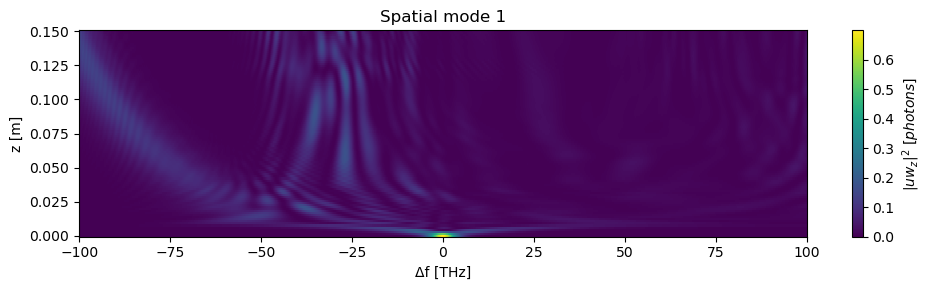

In [18]:
uω_z = sol_disp_mmf["uω_z"]; # uω_z = [L x Nt x M] = [fiber length, time point, spatial modes]

FF, ZZ = MultiModeNoise.meshgrid(sim["fs"] .- sim["f0"], fiber["zsave"]) # create meshgrid for plotting; fs: stop freq, f0: start freq (THz)

fig, axs = subplots(1, M, figsize=(10,3))

if M == 1
    axs = [axs] # Wrap the single object in a list
end

for i in 1:M 
    im = axs[i].pcolormesh(FF, ZZ, abs2.(fftshift(uω_z[:,:,i], 2)) , shading="nearest") # plotting for every sp mode
    fig.colorbar(im, ax=axs[i], label=L"|uw_z|^2\ [photons]") # number of photons; photon-number-normalized power-like quantity (uw_z=sqrt(Nt*dt/hbar/omega0)*Aw_z); Aw_z = [sqrt(power)]
    axs[i].set_title(@sprintf("Spatial mode %d",i))
    axs[i].set_xlim(-100,100)
    axs[i].set_xlabel("Δf [THz]")
    axs[i].set_ylabel("z [m]")
end
fig.tight_layout()
fig

normalize the above color scheme with $\epsilon$ and $N_t$ properly: $u_w(z)\times\sqrt{N_t\epsilon}$

Plotting before and after

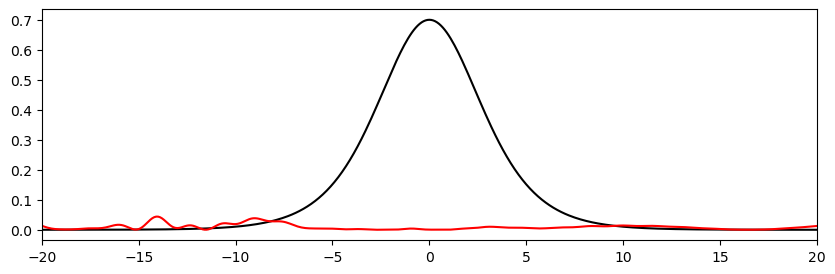

In [19]:
fig2, axs2 = subplots(1, M, figsize=(10, 3))
if M == 1
    axs2 = [axs2] # Wrap the single object in a list
end

for i in 1:M
    im = axs2[i].plot(FF[1, :], abs2.(fftshift(uω_z[1,:,i])), color="black", label="Input")
    im = axs2[i].plot(FF[1, :], abs2.(fftshift(uω_z[end,:,i])), color="red", label="Output")
    axs2[i].set_xlim(-20,20)
end

fig2

# Plotting Wavelength

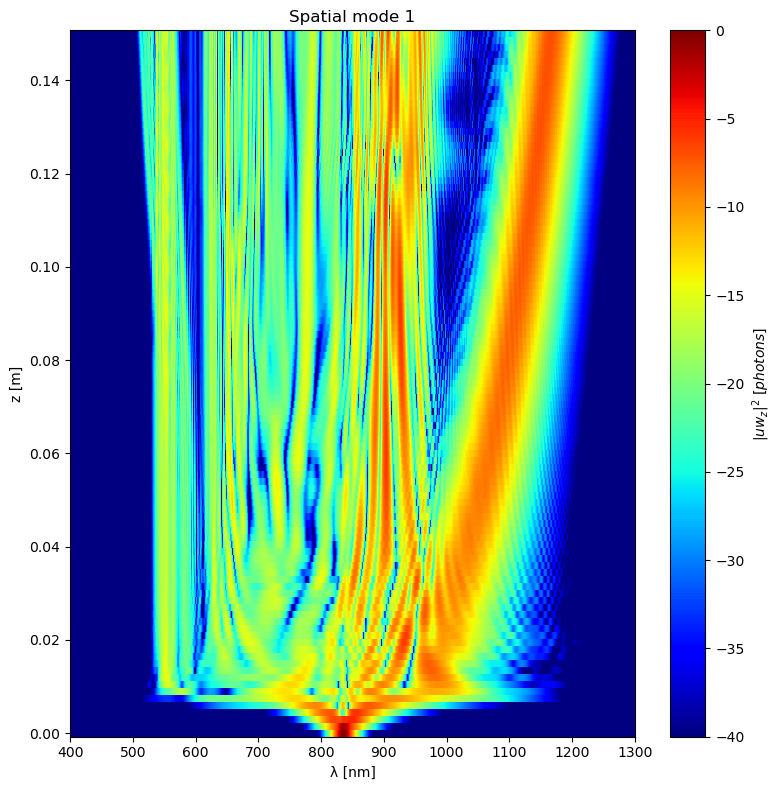

In [23]:
uω_z = sol_disp_mmf["uω_z"]; # uω_z = [L x Nt x M] = [fiber length, time point, spatial modes]

ΛΛ, ZZ = MultiModeNoise.meshgrid(3e8./sim["fs"] * 1e-3, fiber["zsave"]) # create meshgrid for plotting; fs: stop freq, f0: start freq (THz)

fig, axs = subplots(1, M, figsize=(8,8))

if M == 1
    axs = [axs] # Wrap the single object in a list
end

for i in 1:M 

    P = abs2.(fftshift(uω_z[:,:,i], 2))          # linear photons
    P_dB = 10 .* log10.(P ./ maximum(P))

    im = axs[i].pcolormesh(ΛΛ, ZZ, P_dB, shading="nearest", vmin=-40, cmap="jet") # plotting for every sp mode
    fig.colorbar(im, ax=axs[i], label=L"|uw_z|^2\ [photons]") # number of photons; photon-number-normalized power-like quantity (uw_z=sqrt(Nt*dt/hbar/omega0)*Aw_z); Aw_z = [sqrt(power)]
    axs[i].set_title(@sprintf("Spatial mode %d",i))
    axs[i].set_xlim(400,1300)
    axs[i].set_xlabel("λ [nm]")
    axs[i].set_ylabel("z [m]")
end
fig.tight_layout()
fig

In [21]:
# # Interference
# max_power = 25.0 #mW
# power_in = range(0.02, max_power, length=50) .* 1e-3;
# T = 0.51;  # 90/10 split

# power_out = []

# for power in power_in
#     print(@sprintf("\rprogress: %f/%f mW", power*1e3, max_power)); flush(stdout)
#     ut0, uw0 = MultiModeNoise.get_initial_state(u0_modes, power, pulse_fwhm, pulse_rep_rate, "sech_sq", sim); # initial state [Nt x M]

#     # Two branches
#     uw1 = 1im .* sqrt(1-T) .* uw0;
#     uw2 = sqrt(T) .* uw0;

#     # Propagate both
#     sol_disp_mmf_1 = MultiModeNoise.solve_disp_mmf(uw1, fiber, sim);
#     sol_disp_mmf_2 = MultiModeNoise.solve_disp_mmf(uw2, fiber, sim);

#     # Extract both after propagation
#     ut1L = sol_disp_mmf_1["ut_z"];
#     ut2L = sol_disp_mmf_2["ut_z"];

#     # Recombine and find power
#     utL = (1im .* sqrt(1-T) .* ut1L) + (sqrt(T) .* ut2L)

#     push!(power_out, sum(abs2.(utL)) * (time_window / Nt * 1e-12))
# end

In [22]:
# fig3, ax3 = subplots(figsize=(6, 4))
# ax3.plot(power_in ./ pulse_rep_rate .* 1e12, power_out * 1e12, color="blue", marker="o", markersize=3, linestyle="-")
# ax3.set_title("Pin vs Pout")
# ax3.set_xlabel("Power in (pJ)")
# ax3.set_ylabel("Power out (arb.)")
# fig3